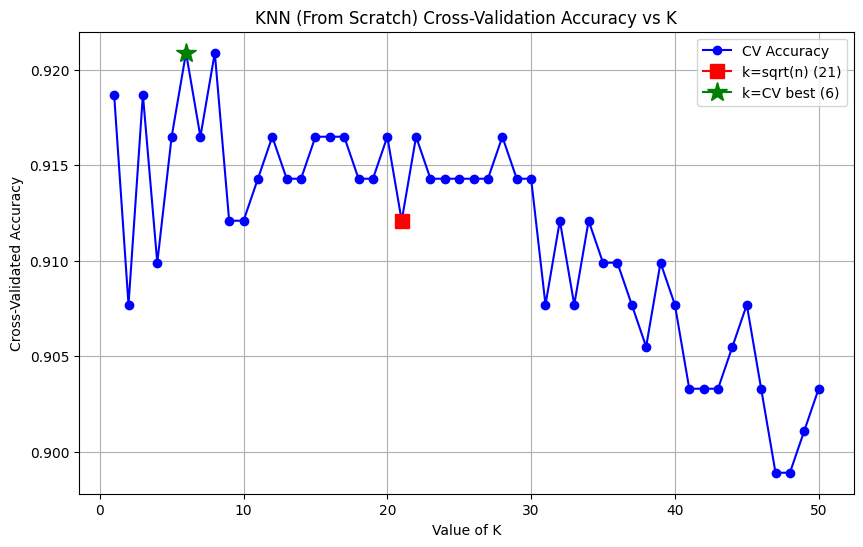

Accuracy for k=sqrt(n) [21]: 0.9649
Accuracy for k=CV optimal [6]: 0.9649


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        distances = [np.sqrt(np.sum((x_train - x) ** 2)) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common

def get_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n = len(X_train)
k_sqrt = int(np.sqrt(n))

knn_sqrt = KNN(k=k_sqrt)
knn_sqrt.fit(X_train, y_train)
y_pred_sqrt = knn_sqrt.predict(X_test)
acc_sqrt = get_accuracy(y_test, y_pred_sqrt)

k_range = range(1, 51)
cv_scores = []
folds = 5
fold_size = len(X_train) // folds
indices = np.arange(len(X_train))
np.random.seed(42)
np.random.shuffle(indices)

for k in k_range:
    scores = []
    for i in range(folds):
        val_idx = indices[i * fold_size : (i + 1) * fold_size]
        train_idx = np.concatenate((indices[:i * fold_size], indices[(i + 1) * fold_size:]))

        X_cv_train, y_cv_train = X_train[train_idx], y_train[train_idx]
        X_cv_val, y_cv_val = X_train[val_idx], y_train[val_idx]

        knn_cv = KNN(k=k)
        knn_cv.fit(X_cv_train, y_cv_train)
        preds = knn_cv.predict(X_cv_val)
        scores.append(get_accuracy(y_cv_val, preds))

    cv_scores.append(np.mean(scores))

k_cv = k_range[np.argmax(cv_scores)]

knn_best = KNN(k=k_cv)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)
acc_best = get_accuracy(y_test, y_pred_best)

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), cv_scores, marker='o', linestyle='-', color='b', label='CV Accuracy')

if k_sqrt in k_range:
    sqrt_index = list(k_range).index(k_sqrt)
    plt.plot(k_sqrt, cv_scores[sqrt_index], marker='s', markersize=10, color='r', label=f'k=sqrt(n) ({k_sqrt})')

cv_index = list(k_range).index(k_cv)
plt.plot(k_cv, cv_scores[cv_index], marker='*', markersize=15, color='g', label=f'k=CV best ({k_cv})')

plt.title('KNN (From Scratch) Cross-Validation Accuracy vs K')
plt.xlabel('Value of K')
plt.ylabel('Cross-Validated Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Accuracy for k=sqrt(n) [{k_sqrt}]: {acc_sqrt:.4f}")
print(f"Accuracy for k=CV optimal [{k_cv}]: {acc_best:.4f}")